In [3]:
import pandas as pd
import pandas_ta as ta

df = pd.read_csv("../../data/MSFT/MSFT.USUSD_Candlestick_5_M_BID_01.09.2022-21.09.2024.csv")
df=df[0:50000]
df=df[df['Volume']!=0]
df["Gmt time"]=df["Gmt time"].str.replace(".000","")
df['Gmt time']=pd.to_datetime(df['Gmt time'],format='%d.%m.%Y %H:%M:%S')
df.rename(columns = {'Gmt time':'datetime_gmt'}, inplace = True)
df['datetime_est']=pd.to_datetime(df["datetime_gmt"], unit='ms').dt.tz_localize('UTC').dt.tz_convert('US/Eastern')

df["Open"] = df.Open.astype(float)
df["High"] = df.High.astype(float)
df["Low"] = df.Low.astype(float)
df["Close"] = df.Close.astype(float)

# Regular hours
df.index = df['datetime_est']
df.between_time("09:30", "16:00")

df.reset_index(drop=True, inplace=True)
df = df[['datetime_est','Open','High','Low','Close','Volume']]
df

,datetime_est,Open,High,Low,Close,Volume
0,2022-09-01 09:30:00-04:00,259.337,259.547,257.896,257.927,2.026800
1,2022-09-01 09:35:00-04:00,257.967,258.957,257.926,258.576,2.226000
2,2022-09-01 09:40:00-04:00,258.547,259.377,258.396,258.737,2.271600
3,2022-09-01 09:45:00-04:00,258.687,259.277,258.466,258.766,2.744400
4,2022-09-01 09:50:00-04:00,258.726,259.147,258.496,259.087,2.450400
...,...,...,...,...,...,...
12064,2023-06-16 15:35:00-04:00,344.027,344.177,343.686,343.926,0.000001
12065,2023-06-16 15:40:00-04:00,343.917,343.966,343.496,343.557,0.000001
12066,2023-06-16 15:45:00-04:00,343.566,344.017,343.506,343.766,0.000001
12067,2023-06-16 15:50:00-04:00,343.746,343.797,342.616,342.737,0.000001


[  4  47 110 152 195 389 453]
[ 27  89 126 172 232 406]


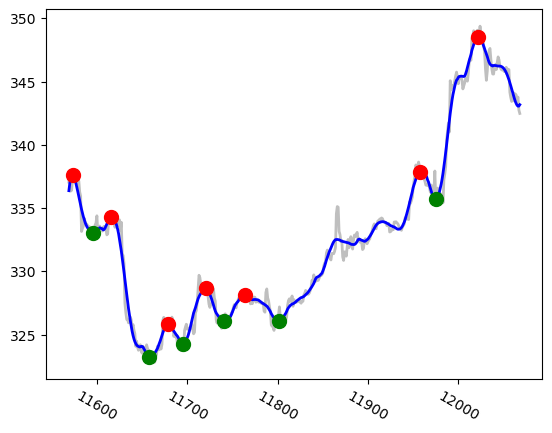

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
pd.set_option('mode.chained_assignment', None)

df2=df[-500:]

atr_window = 30
smooth_window_lenght = 49
polyorder = 5  # Must be less than window_lenght
distance = 15
width = 3

## Take the rolling atr so the yaxis doesn't shake too much 
df["atr"] = ta.atr(high=df.High, low=df.Low, close=df.Close)
df["atr"] = df.atr.rolling(window=atr_window).mean()
df2["close_smooth"] = savgol_filter(df2.Close, smooth_window_lenght, polyorder)

atr = df2.atr.iloc[-1] # all the first atrs are NaN
peaks_idx, _ = find_peaks(df2.close_smooth, distance = distance, width = width, prominence=atr)
troughs_idx, _ = find_peaks(-1*df2.close_smooth, distance = distance, width = width, prominence=atr)

print(peaks_idx)
print(troughs_idx)

# PLOT
fig, ax = plt.subplots()
plt.xticks(rotation=-30)
price, = ax.plot(df2.index, df2.Close, c='grey', lw=2, alpha=0.5, zorder=5)
price_smooth, = ax.plot(df2.index, df2.close_smooth, c='b', lw=2, zorder=5)

peaks, = ax.plot(df2.index[peaks_idx], df2.close_smooth.iloc[peaks_idx], \
                 c="r", linestyle='None', markersize = 10.0, marker = "o", zorder=10)

troughs, = ax.plot(df2.index[troughs_idx], df2.close_smooth.iloc[troughs_idx], \
                   c="g", linestyle='None', markersize = 10.0, marker = "o", zorder=10)

plt.show()

[ 89 153]
[  5 106]
1


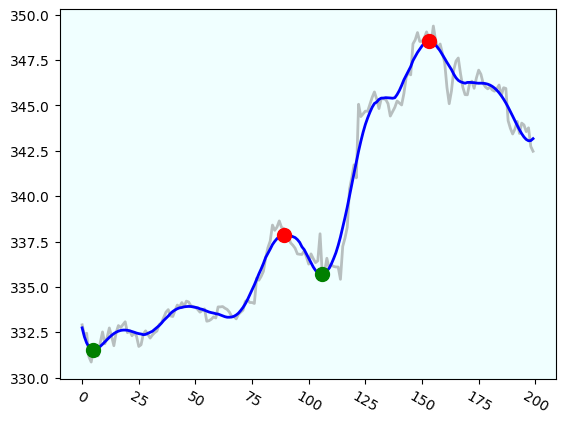

,datetime_est,Open,High,Low,Close,Volume,atr,close_smooth
0,2023-06-13 09:50:00-04:00,333.206,333.307,332.416,332.906,1.650600,0.946678,332.740728
1,2023-06-13 09:55:00-04:00,332.877,333.546,332.006,332.347,1.505700,0.965879,332.249792
2,2023-06-13 10:00:00-04:00,332.407,333.047,332.016,332.446,1.495800,0.988709,331.907746
3,2023-06-13 10:05:00-04:00,332.447,332.697,331.106,331.146,1.682100,1.011730,331.689010
4,2023-06-13 10:10:00-04:00,331.147,331.286,330.376,330.857,1.772100,1.028785,331.570547
...,...,...,...,...,...,...,...,...
195,2023-06-16 15:35:00-04:00,344.027,344.177,343.686,343.926,0.000001,0.707946,343.259417
196,2023-06-16 15:40:00-04:00,343.917,343.966,343.496,343.557,0.000001,0.691700,343.124554
197,2023-06-16 15:45:00-04:00,343.566,344.017,343.506,343.766,0.000001,0.677329,343.053057
198,2023-06-16 15:50:00-04:00,343.746,343.797,342.616,342.737,0.000001,0.689377,343.061849


In [24]:

df2=df[-200:]
df2.reset_index(drop=True, inplace=True)

atr_window = 30
smooth_window_lenght = 49
polyorder = 5  # Must be less than window_lenght
distance = 15
width = 3

## Take the rolling atr so the yaxis doesn't shake too much 
df["atr"] = ta.atr(high=df.High, low=df.Low, close=df.Close)
df["atr"] = df.atr.rolling(window=atr_window).mean()
df2["close_smooth"] = savgol_filter(df2.Close, smooth_window_lenght, polyorder)

atr = df2.atr.iloc[-1] # all the first atrs are NaN
peaks_idx, _ = find_peaks(df2.close_smooth, distance = distance, width = width, prominence=atr)
troughs_idx, _ = find_peaks(-1*df2.close_smooth, distance = distance, width = width, prominence=atr)

'''
Check if we are on a up trend
'''
up_run_length = 0
up_run = True
while up_run:
    if 2 + up_run_length > len(peaks_idx) or 2 + up_run_length > len(troughs_idx):
        break

    peaks1 = df2.close_smooth.iloc[peaks_idx[-1 - up_run_length]]
    peaks2 = df2.close_smooth.iloc[peaks_idx[-2 - up_run_length]]

    troughs1 = df2.close_smooth.iloc[troughs_idx[-1 - up_run_length]]
    troughs2 = df2.close_smooth.iloc[troughs_idx[-2 - up_run_length]]
    
    if peaks1 > peaks2 and troughs1 > troughs2:
        up_run_length += 1
    else:
        up_run = False 

print(peaks_idx)
print(troughs_idx)
print(up_run_length)

# PLOT #
fig, ax = plt.subplots()
plt.xticks(rotation=-30)
price, = ax.plot(df2.index, df2.Close, c='grey', lw=2, alpha=0.5, zorder=5)
price_smooth, = ax.plot(df2.index, df2.close_smooth, c='b', lw=2, zorder=5)

peaks, = ax.plot(df2.index[peaks_idx], df2.close_smooth.iloc[peaks_idx], \
                 c="r", linestyle='None', markersize = 10.0, marker = "o", zorder=10)

troughs, = ax.plot(df2.index[troughs_idx], df2.close_smooth.iloc[troughs_idx], \
                   c="g", linestyle='None', markersize = 10.0, marker = "o", zorder=10)

'''
Set background color
'''
if up_run_length > 0:
    ax.set_facecolor('azure')  
else:
    ax.set_facecolor("white")
    
plt.show()
df2